# Raw Data Tests

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import box

In [2]:
amazon_estuary_bbox = gpd.GeoSeries(box(-55, -4, -47.25, 3.5), crs=4326)
amazon_estuary_zoom_bbox = gpd.GeoSeries(box(-55, -4, -54, -3), crs=4326)

In [3]:
gpd.list_layers("/Users/felixschulz/Downloads/bho_2017_v_01_05_5k.gpkg")

,name,geometry_type
0,pgh_output.geoft_bho_trecho_drenagem,MultiLineString
1,pgh_output.geoft_bho_area_drenagem,MultiPolygon
2,pgh_output.geoft_bho_ponto_drenagem,Point
3,pgh_output.geoft_bho_curso_dagua,MultiLineString
4,pgh_output.geoft_bho_linha_costa,MultiLineString


In [291]:
trenches_subset = gpd.read_file("/Users/felixschulz/Downloads/bho_2017_v_01_05_5k.gpkg", bbox=amazon_estuary_zoom_bbox, layer="pgh_output.geoft_bho_trecho_drenagem")
trenches_subset = trenches_subset[["cotrecho", "nodestino", "noorigem", "nucomptrec", "nudistbact", "geometry"]].copy()
trenches_subset.rename(
    columns={
        "cotrecho": "trench_id", 
        "nodestino": "downstream_node", 
        "noorigem": "upstream_node", 
        "nucomptrec": "distance",
        "nudistbact": "estuary_distance"
        }, 
    inplace=True)

In [ ]:
## compute_subsystems()

import networkx as nx

# Assuming rivers_subset is your GeoDataFrame with 'node_upstream' and 'node_downstream' columns

# Build the directed graph
G = nx.DiGraph()
for _, row in trenches_subset.iterrows():
    G.add_edge(row['upstream_node'], row['downstream_node'])

# Find connected components in the undirected version
components = list(nx.connected_components(G.to_undirected()))

# Create a dictionary mapping node to component ID
node_to_component = {}
for comp_id, component in enumerate(components):
    for node in component:
        node_to_component[node] = comp_id

# Since nodes are tuples (coordinates), we need to map back to rows
# Assuming node_upstream and node_downstream are tuples or can be hashed
trenches_subset['system_id'] = trenches_subset.apply(
    lambda row: node_to_component.get(row['upstream_node'], -1), axis=1
)

In [ ]:
## compute_distance_matrix()

import networkx as nx
from scipy.sparse.csgraph import shortest_path
import numpy as np

# Assuming G is the directed graph from trenches_subset
# And components is the list of connected components

# First, build node to estuary_distance dict
node_estuary_dist = {}
for _, row in trenches_subset.iterrows():
    node_estuary_dist[row['downstream_node']] = row['estuary_distance']
    if row['upstream_node'] not in node_estuary_dist:
        node_estuary_dist[row['upstream_node']] = row['estuary_distance'] + row['distance']

# First, get components if not already
components = list(nx.connected_components(G.to_undirected()))

# Dictionary to store dense reachability matrices by system_id
reachability_matrices = {}

# Dictionary to store dense distance matrices by system_id
distance_matrices = {}

for comp_id, component in enumerate(components):
    subgraph = G.subgraph(component)
    nodes = list(subgraph.nodes())
    
    # Create dense adjacency matrix
    adj_dense = nx.to_numpy_array(subgraph, nodelist=nodes)
    
    # Compute shortest path distances to determine reachability
    dist_dense = shortest_path(adj_dense, directed=True, return_predecessors=False)
    
    # Create reachability matrix: 1 if reachable (finite distance), 0 otherwise
    reach = np.where(np.isfinite(dist_dense), 1, 0)
    
    # Store dense reachability matrix
    reachability_matrices[comp_id] = reach
    
    # Compute distance matrix using estuary_distance differences for reachable pairs
    dist_matrix = np.full_like(reach, np.inf, dtype=float)
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if reach[i, j] == 1:
                dist_matrix[i, j] = node_estuary_dist[nodes[i]] - node_estuary_dist[nodes[j]]
    
    # Store dense distance matrix
    distance_matrices[comp_id] = dist_matrix

# Now, reachability_matrices[system_id] contains the dense reachability matrix for that system
# distance_matrices[system_id] contains the dense distance matrix for that system
# Nodes are in the order of list(subgraph.nodes())


In [292]:
drainage_area_subset = gpd.read_file("/Users/felixschulz/Downloads/bho_2017_v_01_05_5k.gpkg", bbox=amazon_estuary_zoom_bbox, layer="pgh_output.geoft_bho_area_drenagem")
drainage_area_subset = drainage_area_subset[["cotrecho", "nuareacont", "geometry"]].rename(
    columns={
        "nuareacont": "drainage_area",
        "cotrecho": "trench_id"
    },
)

---

# Processed Data Tests

In [1]:
import sys
sys.path.append("..")
from data.river_network import RiverNetwork
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import networkx as nx

In [2]:
network = RiverNetwork()
network.load("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network")
amazon_estuary_zoom_bbox = gpd.GeoSeries(shapely.box(-55, -4, -54, -3), crs=4326)
para_estuary_zoom_bbox = gpd.GeoSeries(shapely.box(-48.25, -.5, -47.25, -1.25), crs=4326)

In [48]:
adm0 = gpd.read_file("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/gadm/gadm41_BRA.gpkg", layer="ADM_ADM_0")
adm0 = adm0.union_all().simplify(.1)

In [55]:
network.drainage_areas["test"] = network.drainage_areas.within(adm0)

<Axes: >

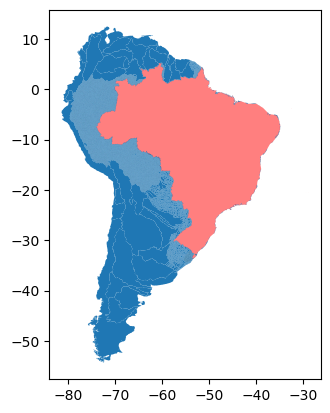

In [57]:
ax = gpd.GeoSeries([adm0]).plot(color="red", alpha=.5)
network.drainage_areas.query("~test").plot(ax=ax)

---

In [51]:
def get_distances(system_id):
    reachability_mask_ = np.isin(
        # all nodes in system S
        network.node_lists[system_id], 
        # upstream nodes of rivers in mun M in system S
        network.trenches.loc[intersection_].query(f"system_id=={system_id}").upstream_node.values
        )
    
    distances_ = network.distance_matrices[system_id][reachability_mask_,].max(axis=0).toarray()[0,:]
    
    distances_df_ = pd.DataFrame({"upstream_node": network.node_lists[system_id], "distance": distances_}).query("distance>0")
    
    return distances_df_

In [52]:
distances_df_ = pd.concat([get_distances(system_id_) for system_id_ in network.trenches.loc[intersection_].system_id.unique()])

<Axes: >

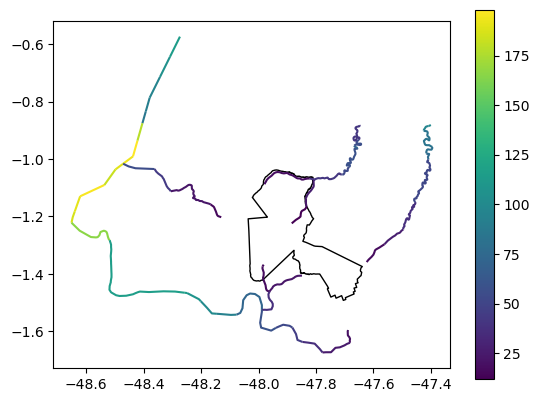

In [53]:
ax = adm2_subset.iloc[[0]].plot(color="none", edgecolor="black")

pd.merge(
    network.trenches,
    distances_df_,
    how="right",
    on="upstream_node"
    ).plot(ax=ax, column="distance_y", legend=True)

In [ ]:
distances_df_